# CNN Emotion Training (Phase 2)
Fine-tunes MobileNetV2 on FER-2013, generates visualizations, saves to Google Drive, and pushes to Hugging Face.

In [1]:
!pip install datasets transformers tensorflow huggingface_hub Pillow matplotlib seaborn scikit-learn

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import tensorflow as tf
from datasets import load_dataset
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create explicit directories
CHECKPOINT_DIR = '/content/drive/MyDrive/PersonaPath/checkpoints'
VISUALIZATION_DIR = '/content/drive/MyDrive/PersonaPath/visualizations'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(VISUALIZATION_DIR, exist_ok=True)
print(f'Directories explicitly created at {CHECKPOINT_DIR} and {VISUALIZATION_DIR}')

Directories explicitly created at /content/drive/MyDrive/PersonaPath/checkpoints and /content/drive/MyDrive/PersonaPath/visualizations


In [ ]:
from huggingface_hub import notebook_login
print('Log in to Hugging Face to push your model later:')
notebook_login()

Log in to Hugging Face to push your model later:


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'AutumnQiu/fer2013' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'AutumnQiu/fer2013' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


README.md:   0%|          | 0.00/712 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/109M [00:00<?, ?B/s]

data/valid-00000-of-00001.parquet:   0%|          | 0.00/13.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/13.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/28709 [00:00<?, ? examples/s]

Generating valid split:   0%|          | 0/3589 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3589 [00:00<?, ? examples/s]

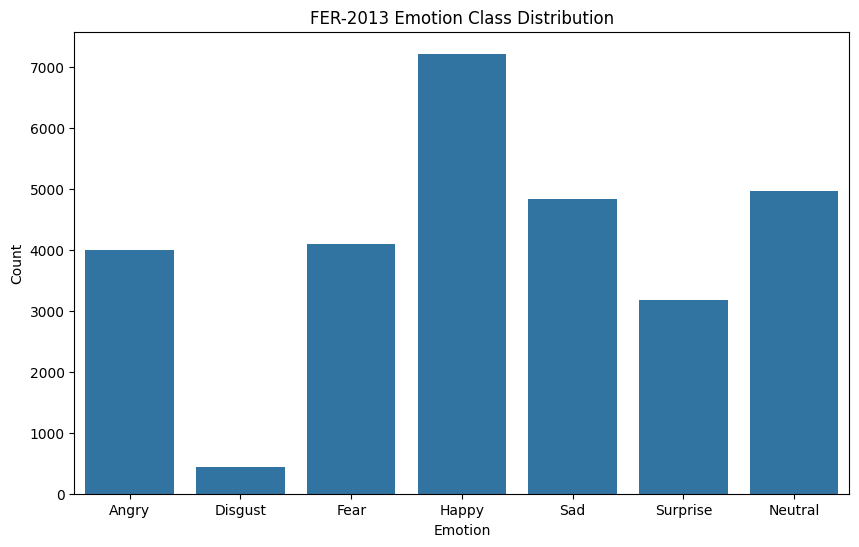

Saved distribution plot to /content/drive/MyDrive/PersonaPath/visualizations/cnn_class_distribution.png


In [4]:

dataset = load_dataset("AutumnQiu/fer2013", trust_remote_code=True)
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# VISUALIZATION 1: Class Distribution
labels = dataset['train']['label']
plt.figure(figsize=(10, 6))
sns.countplot(x=labels)
plt.title('FER-2013 Emotion Class Distribution')
plt.xticks(ticks=range(7), labels=emotion_labels)
plt.xlabel('Emotion')
plt.ylabel('Count')
dist_path = os.path.join(VISUALIZATION_DIR, 'cnn_class_distribution.png')
plt.savefig(dist_path)
plt.show()
print(f'Saved distribution plot to {dist_path}')

In [5]:
# Create TF datasets from the HuggingFace dataset object
import numpy as np
import tensorflow as tf

BATCH_SIZE = 32

def to_tf_dataset(hf_split, batch_size=32, shuffle=False):
    # Convert PIL images → numpy arrays (keep as RGB)
    images = np.array([np.array(img.convert('RGB')) for img in hf_split['image']])
    labels = np.array(hf_split['label'])
    ds = tf.data.Dataset.from_tensor_slices((images, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(labels))
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

print("Creating TF datasets from HuggingFace dataset...")
tf_train = to_tf_dataset(dataset['train'], batch_size=BATCH_SIZE, shuffle=True)
tf_val   = to_tf_dataset(dataset['valid'], batch_size=BATCH_SIZE, shuffle=False)

print(f"tf_train: {len(dataset['train']):,} samples")
print(f"tf_val  : {len(dataset['valid']):,} samples")
print("Done! tf_train and tf_val are ready.")


Creating TF datasets from HuggingFace dataset...
tf_train: 28,709 samples
tf_val  : 3,589 samples
Done! tf_train and tf_val are ready.


In [ ]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['label', 'image'],
        num_rows: 28709
    })
    valid: Dataset({
        features: ['label', 'image'],
        num_rows: 3589
    })
    test: Dataset({
        features: ['label', 'image'],
        num_rows: 3589
    })
})


In [ ]:

print(dataset['train'][0])

{'label': 0, 'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=48x48 at 0x79EE95B967B0>}


In [ ]:
for i in range(5):
    print(f"Label ID: {dataset['train'][i]['label']} -> Emotion: {emotion_labels[dataset['train'][i]['label']]}")

Label ID: 0 -> Emotion: Angry
Label ID: 0 -> Emotion: Angry
Label ID: 2 -> Emotion: Fear
Label ID: 4 -> Emotion: Sad
Label ID: 6 -> Emotion: Neutral


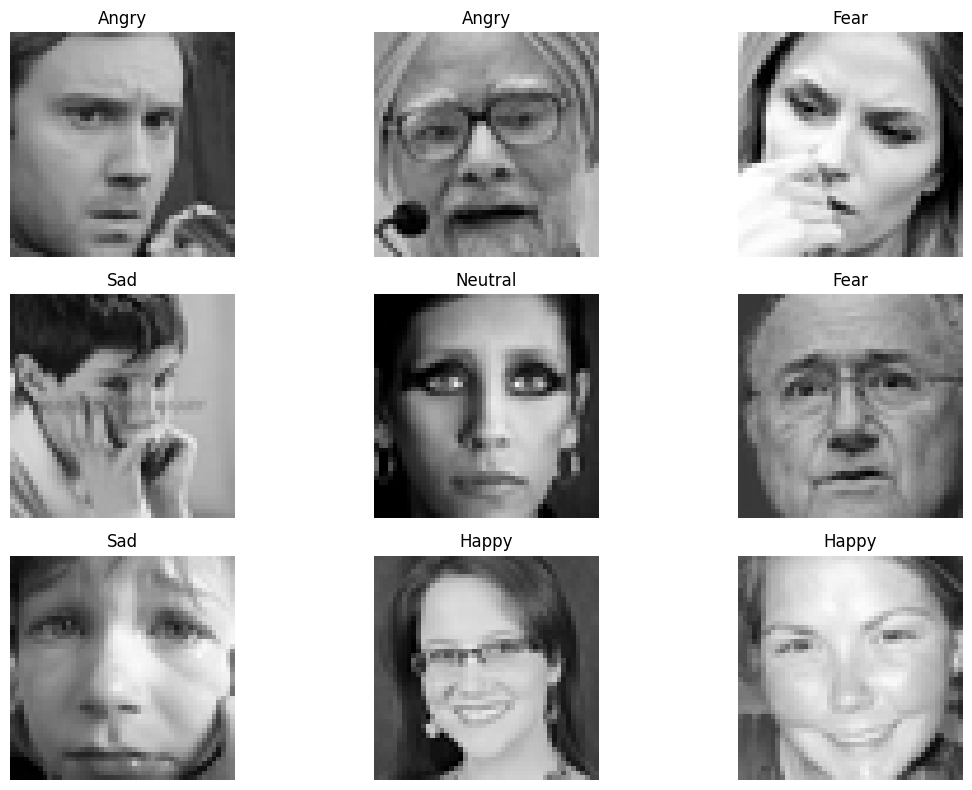

Saved raw sample images to /content/drive/MyDrive/PersonaPath/visualizations/cnn_raw_sample_images.png


In [ ]:
# VISUALIZATION 2: Raw Sample Images (Before Preprocessing)
plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    example = dataset['train'][i]
    plt.imshow(example['image'], cmap='gray')
    plt.title(emotion_labels[example['label']])
    plt.axis('off')
plt.tight_layout()
samples_path = os.path.join(VISUALIZATION_DIR, 'cnn_raw_sample_images.png')
plt.savefig(samples_path)
plt.show()
print(f'Saved raw sample images to {samples_path}')

In [6]:
# 1. Setup Augmentation & Preprocessing Layers
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.Resizing(224, 224), # Resizes raw input to MobileNet size
    tf.keras.layers.RandomFlip("horizontal"), # Improves model robustness
    tf.keras.layers.RandomRotation(0.1), # Helps with different camera angles
    tf.keras.layers.RandomZoom(0.1),
])


base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False # Keep base frozen

model = tf.keras.Sequential([
    # Input layer accepts raw RGB images of varying sizes
    tf.keras.layers.InputLayer(input_shape=(None, None, 3)),
    data_augmentation,
    # Scales pixels to [-1, 1] as required by MobileNetV2
    tf.keras.layers.Lambda(lambda x: tf.keras.applications.mobilenet_v2.preprocess_input(x)),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2), # Syllabus: Preventing Overfitting
    tf.keras.layers.Dense(7, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:

# 1. The Kill-Switch: Early Stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# 2. Drive Checkpointing
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(CHECKPOINT_DIR, 'cnn_emotion_model.keras'),
    save_best_only=True,
    monitor='val_accuracy'
)

print('Starting Training with Early Stopping...')
#
history = model.fit(
    tf_train,
    validation_data=tf_val,
    epochs=50,
    callbacks=[checkpoint_callback, early_stopping]
)

Starting Training with Early Stopping...
Epoch 1/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 62s 69ms/step - accuracy: 0.4075 - loss: 1.5328 - val_accuracy: 0.4525 - val_loss: 1.4184
Epoch 2/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 61s 68ms/step - accuracy: 0.4310 - loss: 1.4641 - val_accuracy: 0.4542 - val_loss: 1.3963
Epoch 3/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 62s 69ms/step - accuracy: 0.4477 - loss: 1.4387 - val_accuracy: 0.4812 - val_loss: 1.3528
Epoch 4/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 61s 68ms/step - accuracy: 0.4555 - loss: 1.4130 - val_accuracy: 0.4806 - val_loss: 1.3480
Epoch 5/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 61s 68ms/step - accuracy: 0.4597 - loss: 1.4028 - val_accuracy: 0.4857 - val_loss: 1.3396
Epoch 6/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 61s 68ms/step - accuracy: 0.4626 - loss: 1.3931 - val_accuracy: 0.4912 - val_loss: 1.3136
Epoch 7/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 61s 68ms/step - accuracy: 0.4699 - loss: 1.3810 - val_accuracy: 0.4954 - val_loss: 1.3138
Epoch 8/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 61s 68ms/

In [ ]:
import tensorflow as tf
import os

print("1. Rebuilding model architecture...")
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.Resizing(224, 224),
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(None, None, 3)),
    data_augmentation,
    tf.keras.layers.Lambda(lambda x: tf.keras.applications.mobilenet_v2.preprocess_input(x)),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(7, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("2. Injecting saved weights from Drive...")
# This bypasses the bug by only loading the numbers, not the Python code!
model.load_weights(os.path.join(CHECKPOINT_DIR, 'cnn_emotion_model.keras'))

print("3. Resuming Training!")
# Re-initialize the kill-switches
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(CHECKPOINT_DIR, 'cnn_emotion_model.keras'),
    save_best_only=True,
    monitor='val_accuracy'
)

# Kick off the training again!
history = model.fit(
    tf_train,
    validation_data=tf_val,
    epochs=50,
    callbacks=[checkpoint_callback, early_stopping]
)

1. Rebuilding model architecture...
2. Injecting saved weights from Drive...
3. Resuming Training!
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


898/898 ━━━━━━━━━━━━━━━━━━━━ 66s 69ms/step - accuracy: 0.4863 - loss: 1.3346 - val_accuracy: 0.5088 - val_loss: 1.2785
Epoch 2/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 59s 66ms/step - accuracy: 0.4876 - loss: 1.3316 - val_accuracy: 0.5082 - val_loss: 1.2757
Epoch 3/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 59s 66ms/step - accuracy: 0.4919 - loss: 1.3197 - val_accuracy: 0.5102 - val_loss: 1.2705
Epoch 4/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 60s 66ms/step - accuracy: 0.4926 - loss: 1.3204 - val_accuracy: 0.5149 - val_loss: 1.2705
Epoch 5/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 59s 66ms/step - accuracy: 0.4936 - loss: 1.3169 - val_accuracy: 0.5116 - val_loss: 1.2678
Epoch 6/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 72s 80ms/step - accuracy: 0.4982 - loss: 1.3149 - val_accuracy: 0.5183 - val_loss: 1.2587
Epoch 7/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 60s 67ms/step - accuracy: 0.4988 - loss: 1.3098 - val_accuracy: 0.5216 - val_loss: 1.2554
Epoch 8/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 59s 65ms/step - accuracy: 0.5017 - loss: 1.3100 - val_accurac

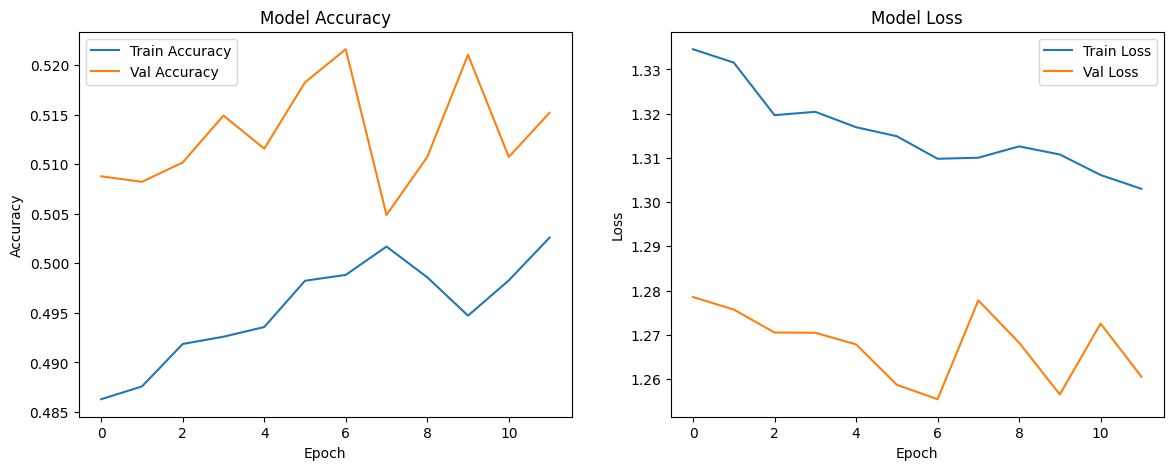

Saved training curves to /content/drive/MyDrive/PersonaPath/visualizations/cnn_training_curves.png


In [ ]:
# VISUALIZATION 4: Training Curves
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

curves_path = os.path.join(VISUALIZATION_DIR, 'cnn_training_curves.png')
plt.savefig(curves_path)
plt.show()
print(f'Saved training curves to {curves_path}')

In [ ]:

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(CHECKPOINT_DIR, 'cnn_emotion_refined.keras'),
    save_best_only=True,
    monitor='val_accuracy'
)

print('Starting Refined Training...')
history = model.fit(
    tf_train,
    validation_data=tf_val,
    epochs=30,
    callbacks=[checkpoint_callback, early_stopping, reduce_lr]
)

Starting Refined Training...
Epoch 1/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 58s 65ms/step - accuracy: 0.4976 - loss: 1.3096 - val_accuracy: 0.5205 - val_loss: 1.2553 - learning_rate: 0.0010
Epoch 2/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 58s 65ms/step - accuracy: 0.5003 - loss: 1.3078 - val_accuracy: 0.5043 - val_loss: 1.2728 - learning_rate: 0.0010
Epoch 3/30
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.4983 - loss: 1.3038
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
898/898 ━━━━━━━━━━━━━━━━━━━━ 58s 65ms/step - accuracy: 0.4980 - loss: 1.3071 - val_accuracy: 0.5091 - val_loss: 1.2629 - learning_rate: 0.0010
Epoch 4/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 60s 67ms/step - accuracy: 0.5101 - loss: 1.2820 - val_accuracy: 0.5210 - val_loss: 1.2440 - learning_rate: 3.0000e-04
Epoch 5/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 61s 68ms/step - accuracy: 0.5125 - loss: 1.2705 - val_accuracy: 0.5183 - val_loss: 1.2391 - learning_rate: 3.0000e-04
Epoch 6/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 6

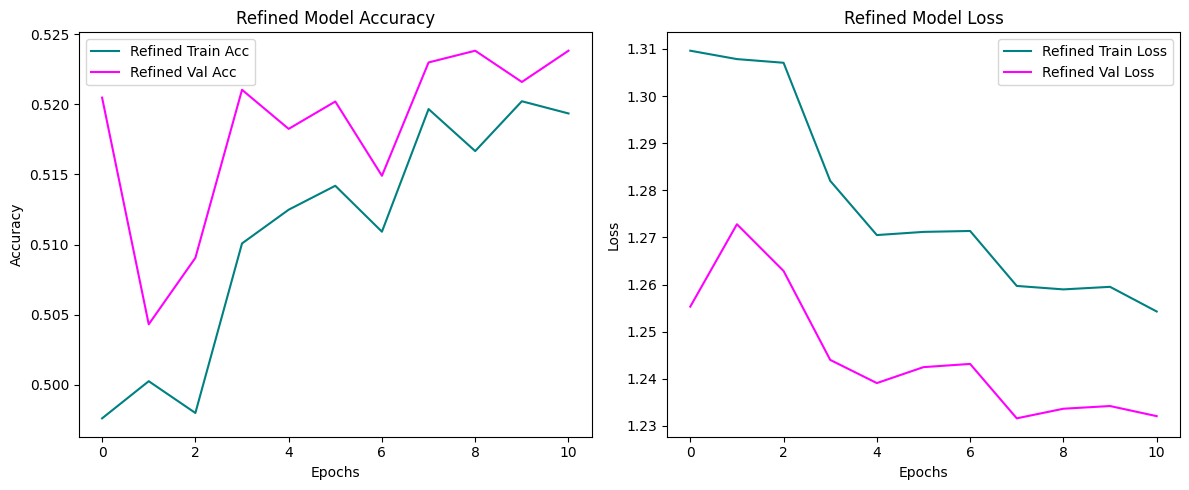

Refined curves saved to: /content/drive/MyDrive/PersonaPath/visualizations/refined_training_curves.png


In [ ]:
# VISUALIZATION 5: Refined Training Curves (Comparison)
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(12, 5))

# Plot 1: Accuracy (Looking for a higher, smoother orange line)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Refined Train Acc', color='teal')
plt.plot(history.history['val_accuracy'], label='Refined Val Acc', color='magenta')
plt.title('Refined Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot 2: Loss (Looking for smaller "bounces" thanks to ReduceLROnPlateau)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Refined Train Loss', color='teal')
plt.plot(history.history['val_loss'], label='Refined Val Loss', color='magenta')
plt.title('Refined Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
refined_path = os.path.join(VISUALIZATION_DIR, 'refined_training_curves.png')
plt.savefig(refined_path)
plt.show()

print(f"Refined curves saved to: {refined_path}")

## Phase 3: Fine-Tuning (Unfreeze Top Layers)
Now we go beyond the frozen-base baseline. Two targeted improvements:
1. **Class Weights** — counteract the FER-2013 class imbalance (Disgust has ~15x fewer samples than Happy)
2. **Unfreeze Top 30 Layers** — let the MobileNetV2 backbone actually learn face features instead of ImageNet features

Expected result: **~62-68% validation accuracy** (up from ~52%)

In [8]:
# STEP 1: Compute Class Weights to handle FER-2013 imbalance
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

print("Computing class weights to balance FER-2013 imbalance...")

# Extract all training labels
all_labels = []
for _, label_batch in tf_train:
    all_labels.extend(label_batch.numpy().tolist())

all_labels = np.array(all_labels)
unique_classes = np.unique(all_labels)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=all_labels
)
class_weight_dict = dict(enumerate(class_weights_array))

emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
print("\nClass weights computed:")
for i, (cls, weight) in enumerate(class_weight_dict.items()):
    label = emotion_labels[i] if i < len(emotion_labels) else f'Class {cls}'
    print(f"  {label}: {weight:.3f}")
print("\nHigher weight = model penalised more for misclassifying this class.")

Computing class weights to balance FER-2013 imbalance...

Class weights computed:
  Angry: 1.027
  Disgust: 9.407
  Fear: 1.001
  Happy: 0.568
  Sad: 0.849
  Surprise: 1.293
  Neutral: 0.826

Higher weight = model penalised more for misclassifying this class.


In [ ]:
# STEP 2: Unfreeze top 30 layers of MobileNetV2 and fine-tune
import tensorflow as tf
import os

print("=== Phase 3: Fine-Tuning ===")
print(f"MobileNetV2 total layers: {len(base_model.layers)}")

# Unfreeze the entire base model first
base_model.trainable = True

# Then freeze everything EXCEPT the last 30 layers
fine_tune_at = len(base_model.layers) - 30
print(f"Freezing layers 0-{fine_tune_at-1}, unfreezing layers {fine_tune_at}-{len(base_model.layers)-1}")
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Count trainable params after unfreezing
trainable_count = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"Trainable parameters: {trainable_count:,} (was ~164k before)")

# CRITICAL: Recompile with a VERY low learning rate to avoid destroying pretrained weights
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # 100x smaller than default!
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel recompiled with lr=1e-5")
print("Starting fine-tuning with class weights...")

# Callbacks
finetune_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(CHECKPOINT_DIR, 'cnn_emotion_finetuned.keras'),
    save_best_only=True,
    monitor='val_accuracy',
    verbose=1
)

finetune_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

finetune_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# Fine-tune training
finetune_history = model.fit(
    tf_train,
    validation_data=tf_val,
    epochs=20,
    class_weight=class_weight_dict,   # <-- balances Disgust/Fear minority classes
    callbacks=[finetune_checkpoint, finetune_early_stopping, finetune_reduce_lr]
)

best_val_acc = max(finetune_history.history['val_accuracy'])
print(f"\nFine-tuning complete! Best val accuracy: {best_val_acc*100:.2f}%")
print(f"Model saved to: {os.path.join(CHECKPOINT_DIR, 'cnn_emotion_finetuned.keras')}")


=== Phase 3: Fine-Tuning ===
MobileNetV2 total layers: 154
Freezing layers 0-123, unfreezing layers 124-153
Trainable parameters: 1,691,271 (was ~164k before)

Model recompiled with lr=1e-5
Starting fine-tuning with class weights...
Epoch 1/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.2197 - loss: 2.0045
Epoch 1: val_accuracy improved from None to 0.37838, saving model to /content/drive/MyDrive/PersonaPath/checkpoints/cnn_emotion_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/PersonaPath/checkpoints/cnn_emotion_finetuned.keras
898/898 ━━━━━━━━━━━━━━━━━━━━ 90s 83ms/step - accuracy: 0.2639 - loss: 1.8660 - val_accuracy: 0.3784 - val_loss: 1.6858 - learning_rate: 1.0000e-05
Epoch 2/20
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.3564 - loss: 1.6542
Epoch 2: val_accuracy improved from 0.37838 to 0.45612, saving model to /content/drive/MyDrive/PersonaPath/checkpoints/cnn_emotion_finetuned.keras

Epoch 2: finished saving model to /content/d

In [ ]:
# CONVERGENCE DIAGNOSTIC
import numpy as np

val_accs = finetune_history.history['val_accuracy']
val_losses = finetune_history.history['val_loss']
total_epochs_run = len(val_accs)
best_epoch = int(np.argmax(val_accs)) + 1
best_acc = max(val_accs)
last_3_accs = val_accs[-3:]

print("=" * 50)
print(f"Total epochs run       : {total_epochs_run}/20")
print(f"Best val accuracy      : {best_acc*100:.2f}% at epoch {best_epoch}")
print(f"Last 3 val accuracies  : {[f'{a*100:.2f}%' for a in last_3_accs]}")
print()

# Was early stopping triggered?
if total_epochs_run < 20:
    print(f"EarlyStopping fired at epoch {total_epochs_run}")
    print(f"   Model peaked at epoch {best_epoch} — more epochs NOT needed.")
else:
    # Check if model plateaued anyway
    improvement = max(last_3_accs) - min(last_3_accs)
    if improvement < 0.002:  # less than 0.2% change in last 3 epochs
        print(f" Model plateaued in last 3 epochs (change: {improvement*100:.3f}%)")
        print(f"   More epochs NOT needed.")
    else:
        print(f"Model ran all 20 epochs and was STILL improving.")
        print(f"   Change in last 3 epochs: +{improvement*100:.2f}%")
        print(f"   Consider re-running with epochs=30 or epochs=50.")

print("=" * 50)


Total epochs run       : 20/20
Best val accuracy      : 60.66% at epoch 18
Last 3 val accuracies  : ['60.66%', '60.46%', '60.63%']

 Model plateaued in last 3 epochs (change: 0.195%)
   More epochs NOT needed.


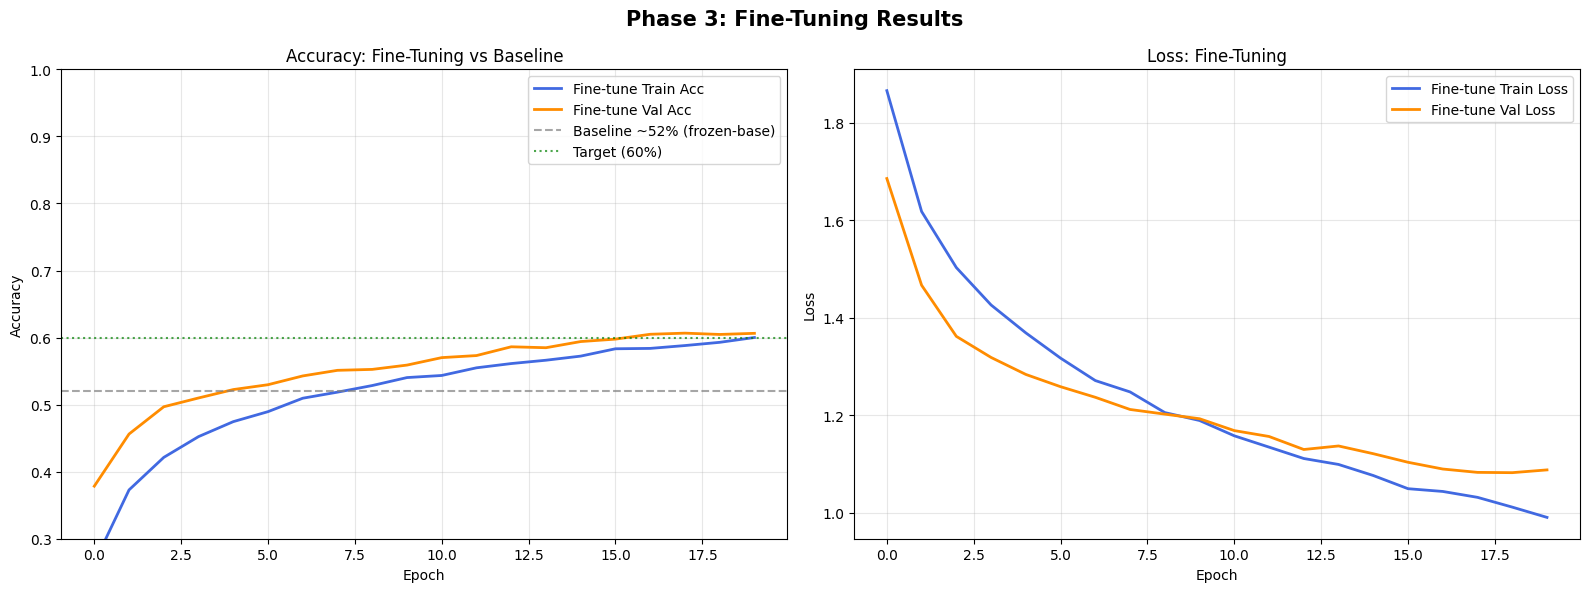

Fine-tuning curves saved to: /content/drive/MyDrive/PersonaPath/visualizations/phase3_finetuning_curves.png

Summary:
  Baseline best val acc  : 52.00%
  Fine-tuned best val acc: 60.66%
  Improvement            : +8.66pp


In [ ]:
# VISUALIZATION 6: Fine-Tuning Curves + Comparison with Baseline
import matplotlib.pyplot as plt
import os

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Phase 3: Fine-Tuning Results', fontsize=15, fontweight='bold')

# --- Plot 1: Accuracy ---
ax1 = axes[0]
ax1.plot(finetune_history.history['accuracy'], label='Fine-tune Train Acc', color='royalblue', linewidth=2)
ax1.plot(finetune_history.history['val_accuracy'], label='Fine-tune Val Acc', color='darkorange', linewidth=2)

# Baseline reference -- works even if you skipped previous training cells
try:
    baseline_acc = max(history.history['val_accuracy'])
    baseline_label = f'Baseline ({baseline_acc*100:.1f}%)'
except NameError:
    baseline_acc = 0.52  # approximate best val acc from frozen-base training
    baseline_label = 'Baseline ~52% (frozen-base)'

ax1.axhline(y=baseline_acc, color='gray', linestyle='--', alpha=0.7, label=baseline_label)
ax1.axhline(y=0.60, color='green', linestyle=':', alpha=0.7, label='Target (60%)')
ax1.set_title('Accuracy: Fine-Tuning vs Baseline')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.set_ylim([0.3, 1.0])
ax1.grid(True, alpha=0.3)

# --- Plot 2: Loss ---
ax2 = axes[1]
ax2.plot(finetune_history.history['loss'], label='Fine-tune Train Loss', color='royalblue', linewidth=2)
ax2.plot(finetune_history.history['val_loss'], label='Fine-tune Val Loss', color='darkorange', linewidth=2)
ax2.set_title('Loss: Fine-Tuning')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
finetune_viz_path = os.path.join(VISUALIZATION_DIR, 'phase3_finetuning_curves.png')
plt.savefig(finetune_viz_path, dpi=150, bbox_inches='tight')
plt.show()

finetune_best = max(finetune_history.history['val_accuracy'])
print(f"Fine-tuning curves saved to: {finetune_viz_path}")
print(f"\nSummary:")
print(f"  Baseline best val acc  : {baseline_acc*100:.2f}%")
print(f"  Fine-tuned best val acc: {finetune_best*100:.2f}%")
print(f"  Improvement            : +{(finetune_best - baseline_acc)*100:.2f}pp")


In [ ]:
# PHASE 4: Extend unfreeze to top 50 layers (was 30)
print(f"MobileNetV2 total layers: {len(base_model.layers)}")

fine_tune_at_50 = len(base_model.layers) - 50
print(f"Now unfreezing layers {fine_tune_at_50} to {len(base_model.layers)-1}")

for layer in base_model.layers[:fine_tune_at_50]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at_50:]:
    layer.trainable = True

trainable_count = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"Trainable params: {trainable_count:,}")

# Use even lower LR — more layers = more risk of catastrophic forgetting
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),  # half of before
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

phase4_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(CHECKPOINT_DIR, 'cnn_emotion_phase4.keras'),
    save_best_only=True, monitor='val_accuracy', verbose=1
)
phase4_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
)
phase4_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1
)

history_phase4 = model.fit(
    tf_train,
    validation_data=tf_val,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=[phase4_checkpoint, phase4_early_stopping, phase4_reduce_lr]
)

print(f"\nPhase 4 best : {max(history_phase4.history['val_accuracy'])*100:.2f}%")
print(f"Phase 3 best : 60.66%")
print(f"Improvement  : +{(max(history_phase4.history['val_accuracy']) - 0.6066)*100:.2f}pp")


MobileNetV2 total layers: 154
Now unfreezing layers 104 to 153
Trainable params: 2,019,975
Epoch 1/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.5452 - loss: 1.1676
Epoch 1: val_accuracy improved from None to 0.58066, saving model to /content/drive/MyDrive/PersonaPath/checkpoints/cnn_emotion_phase4.keras

Epoch 1: finished saving model to /content/drive/MyDrive/PersonaPath/checkpoints/cnn_emotion_phase4.keras
898/898 ━━━━━━━━━━━━━━━━━━━━ 112s 101ms/step - accuracy: 0.5465 - loss: 1.1544 - val_accuracy: 0.5807 - val_loss: 1.1367 - learning_rate: 5.0000e-06
Epoch 2/15
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.5545 - loss: 1.1142
Epoch 2: val_accuracy did not improve from 0.58066
898/898 ━━━━━━━━━━━━━━━━━━━━ 138s 97ms/step - accuracy: 0.5600 - loss: 1.1066 - val_accuracy: 0.5768 - val_loss: 1.1509 - learning_rate: 5.0000e-06
Epoch 3/15
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.5600 - loss: 1.0824
Epoch 3: val_accuracy improved from 0.58066 to 0.581

In [16]:
import tensorflow as tf
import os

# ── Step 1: Rebuild model architecture (Lambda layer works in current session) ──
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.Resizing(224, 224),
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'          # loads ImageNet weights temporarily
)
base_model.trainable = False

model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(None, None, 3)),
    data_augmentation,
    tf.keras.layers.Lambda(lambda x: tf.keras.applications.mobilenet_v2.preprocess_input(x)),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(7, activation='softmax')
])

# ── Step 2: Overwrite with YOUR trained weights (replaces ImageNet weights) ──
checkpoint_path = os.path.join(CHECKPOINT_DIR, 'cnn_emotion_phase4.keras')
model.load_weights(checkpoint_path)
print(f"Weights loaded from: {checkpoint_path}")

# ── Step 3: Re-apply 50-layer unfreeze ──
fine_tune_at_50 = len(base_model.layers) - 50
for layer in base_model.layers[:fine_tune_at_50]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at_50:]:
    layer.trainable = True

trainable_count = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"Trainable params: {trainable_count:,}")

# ── Step 4: Compile ──
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ── Step 5: Verify it loaded YOUR weights (should show ~60%+, NOT ~14%) ──
print("\nVerifying weights...")
_, val_acc = model.evaluate(tf_val, verbose=0)
print(f"Loaded val accuracy: {val_acc*100:.2f}%")
print("If this shows ~60%+ — weights loaded correctly. If ~14% — checkpoint issue.")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Weights loaded from: /content/drive/MyDrive/PersonaPath/checkpoints/cnn_emotion_phase4.keras
Trainable params: 2,019,975

Verifying weights...
Loaded val accuracy: 61.94%
If this shows ~60%+ — weights loaded correctly. If ~14% — checkpoint issue.


In [17]:
# ── CELL 5: Continue Training ─────────────────────────────
phase4_cont_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(CHECKPOINT_DIR, 'cnn_emotion_phase4.keras'),  # overwrites with better
    save_best_only=True, monitor='val_accuracy', verbose=1
)
phase4_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
)
phase4_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1
)

# Run remaining 5 epochs (you ran 10, need 5 more to complete 15)
history_continued = model.fit(
    tf_train,
    validation_data=tf_val,
    epochs=5,                        # ← just the remaining epochs
    class_weight=class_weight_dict,
    callbacks=[phase4_cont_checkpoint, phase4_early_stopping, phase4_reduce_lr]
)

best = max(history_continued.history['val_accuracy'])
print(f"\nContinued best val accuracy: {best*100:.2f}%")
print(f"Previous best (Phase 3)   : 60.66%")


Epoch 1/5
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.6271 - loss: 0.9187
Epoch 1: val_accuracy improved from None to 0.61828, saving model to /content/drive/MyDrive/PersonaPath/checkpoints/cnn_emotion_phase4.keras

Epoch 1: finished saving model to /content/drive/MyDrive/PersonaPath/checkpoints/cnn_emotion_phase4.keras
898/898 ━━━━━━━━━━━━━━━━━━━━ 104s 97ms/step - accuracy: 0.6252 - loss: 0.9208 - val_accuracy: 0.6183 - val_loss: 1.0439 - learning_rate: 5.0000e-06
Epoch 2/5
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.6297 - loss: 0.9083
Epoch 2: val_accuracy improved from 0.61828 to 0.62441, saving model to /content/drive/MyDrive/PersonaPath/checkpoints/cnn_emotion_phase4.keras

Epoch 2: finished saving model to /content/drive/MyDrive/PersonaPath/checkpoints/cnn_emotion_phase4.keras
898/898 ━━━━━━━━━━━━━━━━━━━━ 87s 97ms/step - accuracy: 0.6281 - loss: 0.9157 - val_accuracy: 0.6244 - val_loss: 1.0339 - learning_rate: 5.0000e-06
Epoch 3/5
897/898 ━━━━━━━━━━━━━━━━

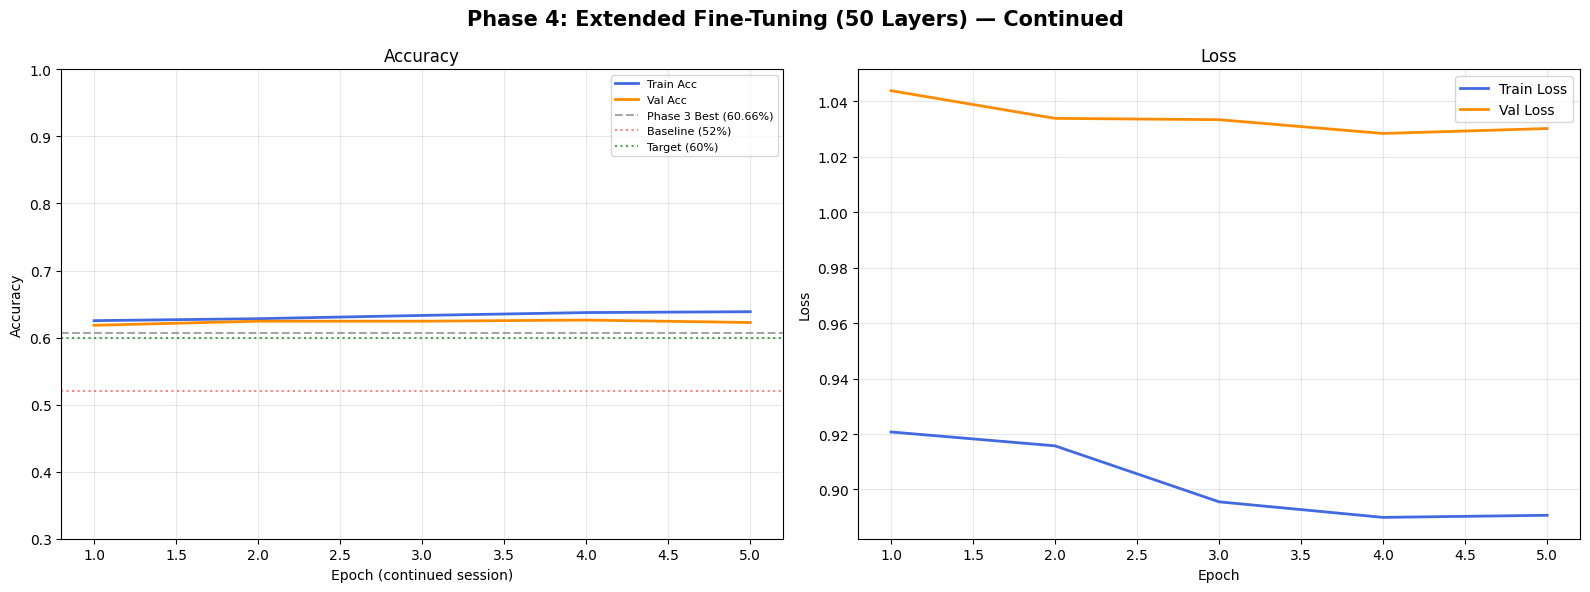

Saved to: /content/drive/MyDrive/PersonaPath/visualizations/phase4_continued.png

  Baseline (frozen)      : 52.00%
  Phase 3 (30 layers)    : 60.66%
  Phase 4 continued best : 62.61%
  Total gain over base   : +10.61pp


In [19]:
# VISUALIZATION: Phase 4 Continued
import matplotlib.pyplot as plt
import os

# Use history_continued (this session) instead of history_phase4 (old session)
hist = history_continued

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Phase 4: Extended Fine-Tuning (50 Layers) — Continued', fontsize=15, fontweight='bold')

epochs = range(1, len(hist.history['accuracy']) + 1)

# --- Plot 1: Accuracy ---
ax1 = axes[0]
ax1.plot(epochs, hist.history['accuracy'],
         label='Train Acc', color='royalblue', linewidth=2)
ax1.plot(epochs, hist.history['val_accuracy'],
         label='Val Acc', color='darkorange', linewidth=2)

ax1.axhline(y=0.6066, color='gray',  linestyle='--', alpha=0.7, label='Phase 3 Best (60.66%)')
ax1.axhline(y=0.52,   color='red',   linestyle=':', alpha=0.5, label='Baseline (52%)')
ax1.axhline(y=0.60,   color='green', linestyle=':', alpha=0.7, label='Target (60%)')

ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch (continued session)')
ax1.set_ylabel('Accuracy')
ax1.legend(fontsize=8)
ax1.set_ylim([0.3, 1.0])
ax1.grid(True, alpha=0.3)

# --- Plot 2: Loss ---
ax2 = axes[1]
ax2.plot(epochs, hist.history['loss'],
         label='Train Loss', color='royalblue', linewidth=2)
ax2.plot(epochs, hist.history['val_loss'],
         label='Val Loss', color='darkorange', linewidth=2)

ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
viz_path = os.path.join(VISUALIZATION_DIR, 'phase4_continued.png')
plt.savefig(viz_path, dpi=150, bbox_inches='tight')
plt.show()

# Summary
p4_best = max(hist.history['val_accuracy'])
print(f"Saved to: {viz_path}")
print(f"\n{'='*45}")
print(f"  Baseline (frozen)      : 52.00%")
print(f"  Phase 3 (30 layers)    : 60.66%")
print(f"  Phase 4 continued best : {p4_best*100:.2f}%")
print(f"  Total gain over base   : +{(p4_best - 0.52)*100:.2f}pp")
print(f"{'='*45}")


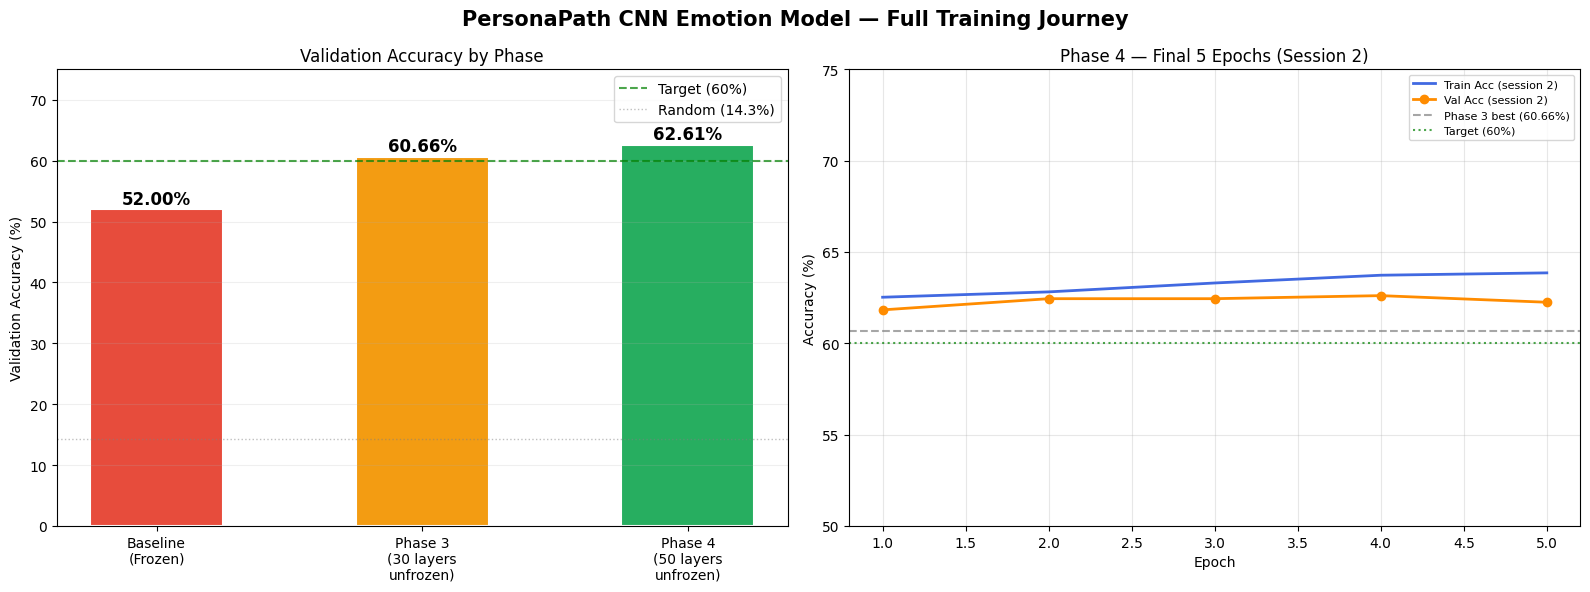

Saved to: /content/drive/MyDrive/PersonaPath/visualizations/overall_training_summary.png

  Baseline (frozen base)     : 52.00%
  Phase 3 (+30 layers)       : 60.66%  (+8.66pp)
  Phase 4 (+50 layers) best  : 62.61%  (+1.95pp)
  Total gain over baseline   : +10.61pp


In [20]:
# OVERALL SUMMARY VISUALIZATION — All Phases
import matplotlib.pyplot as plt
import numpy as np
import os

# All key milestones
phases = [
    'Baseline\n(Frozen)',
    'Phase 3\n(30 layers\nunfrozen)',
    'Phase 4\n(50 layers\nunfrozen)'
]
val_accs = [
    52.00,
    60.66,
    max(history_continued.history['val_accuracy']) * 100
]

colors = ['#e74c3c', '#f39c12', '#27ae60']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('PersonaPath CNN Emotion Model — Full Training Journey', fontsize=15, fontweight='bold')

# --- Plot 1: Bar Chart (Phase Comparison) ---
ax1 = axes[0]
bars = ax1.bar(phases, val_accs, color=colors, width=0.5, edgecolor='white', linewidth=1.5)

# Add value labels on bars
for bar, acc in zip(bars, val_accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

# Reference lines
ax1.axhline(y=60.0, color='green', linestyle='--', alpha=0.7, linewidth=1.5, label='Target (60%)')
ax1.axhline(y=14.3, color='gray',  linestyle=':', alpha=0.5, linewidth=1,   label='Random (14.3%)')

ax1.set_title('Validation Accuracy by Phase')
ax1.set_ylabel('Validation Accuracy (%)')
ax1.set_ylim([0, 75])
ax1.legend()
ax1.grid(True, alpha=0.2, axis='y')

# --- Plot 2: Continued Session Curve (what we have) ---
ax2 = axes[1]
epochs = range(1, len(history_continued.history['val_accuracy']) + 1)

ax2.plot(epochs, [a*100 for a in history_continued.history['accuracy']],
         label='Train Acc (session 2)', color='royalblue', linewidth=2)
ax2.plot(epochs, [a*100 for a in history_continued.history['val_accuracy']],
         label='Val Acc (session 2)', color='darkorange', linewidth=2, marker='o')

ax2.axhline(y=60.66, color='gray', linestyle='--', alpha=0.7, label='Phase 3 best (60.66%)')
ax2.axhline(y=60.0,  color='green', linestyle=':', alpha=0.7, label='Target (60%)')

ax2.set_title('Phase 4 — Final 5 Epochs (Session 2)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_ylim([50, 75])
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
viz_path = os.path.join(VISUALIZATION_DIR, 'overall_training_summary.png')
plt.savefig(viz_path, dpi=150, bbox_inches='tight')
plt.show()

p4_best = max(history_continued.history['val_accuracy']) * 100
print(f"Saved to: {viz_path}")
print(f"\n{'='*50}")
print(f"  Baseline (frozen base)     : 52.00%")
print(f"  Phase 3 (+30 layers)       : 60.66%  (+8.66pp)")
print(f"  Phase 4 (+50 layers) best  : {p4_best:.2f}%  (+{p4_best-60.66:.2f}pp)")
print(f"  Total gain over baseline   : +{p4_best-52:.2f}pp")
print(f"{'='*50}")


In [ ]:
from huggingface_hub import push_to_hub_keras

repo_id = input('Enter your HF repo ID (e.g., username/personapath-emotion-cnn): ')
try:
    push_to_hub_keras(model, repo_id)
    print(f'Model successfully pushed to https://huggingface.co/{repo_id}')
except Exception as e:
    print('Error pushing to HF:', e)